In [1]:
%load_ext autoreload
%autoreload 2
%env https_proxy=http://proxy:80
%env http_proxy=http://proxy:80

from tqdm.notebook import tqdm
import torch
from torchvision import datasets, models, transforms
import os

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from utils import CatsLoader, plot, normalize, denormalize, system_startup
setup = system_startup()
device = setup['device']


env: https_proxy=http://proxy:80
env: http_proxy=http://proxy:80
Currently evaluating -------------------------------:
Sunday, 01. December 2024 09:21PM
CPUs: 8, GPUs: 1 on tg067.
GPU : NVIDIA GeForce RTX 2080 Ti


In [2]:
# You can turn this of after your first walk through the notebook to speed up consecutive runs
run_tests = True

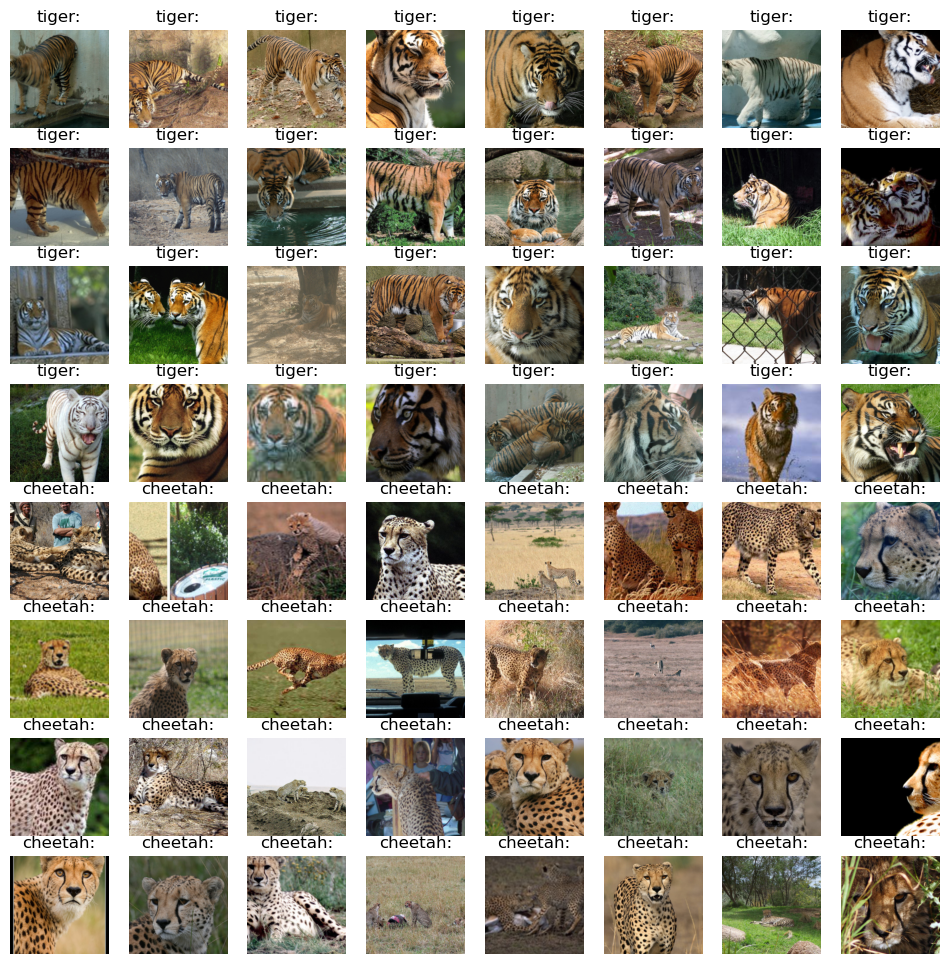

In [ ]:
# Load the images into memory, make sure you extraced the provided zip file in the same directory as this notebook.
force_image_loading = False
has_loaded_once = 'has_loaded_once' in globals()
if not has_loaded_once or force_image_loading:
     # Initialize the data loader
     data_dir = './imagenet-tiger-vs-cheetah'
     dataloader = CatsLoader(data_dir)

     # Load all images and labels from the dataloader
     # We load them already here bacause that makes modification and filtering easier
     clean_training_images, clean_training_labels, val_images, val_labels = dataloader.load_images()
     val_images, val_labels = (val_images.to(device), val_labels.to(device))

     # Filter the images and labels to only include tigers and leopards
     tiger_label = 0
     cheetah_label = 1
     # Split the training set into tiger and cheetah images
     tiger_images = clean_training_images[clean_training_labels == tiger_label]
     cheetah_images = clean_training_images[clean_training_labels == cheetah_label]

     has_loaded_once = True
     del clean_training_images, clean_training_labels, dataloader, data_dir

if run_tests:
     # Have a look at these beautiful cats
     num_of_each = 8 ** 2 // 2
     plot(denormalize(torch.cat((tiger_images[:num_of_each], cheetah_images[:num_of_each]))),
          ['tiger:']*num_of_each + ['cheetah:']*num_of_each)

In [ ]:
# We use alexnet as in the HTBA paper, feel free to try out other models LATER
arch = 'alexnet'
def get_model(arch = arch, features_only=False):
    """ Returns a model with the last layer modified for binary classification and all other layers freezed.
    If features_only is set to True, the last layer will be replaced by an identity layer
    Args:
        arch: str, model architecture, 'alexnet' or 'resnet18'
        features_only: whethere to return a model for feature extraction or binary classification
    """
    if arch == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = model.fc.in_features
        model.fc = nn.Identity() if features_only else nn.Linear(num_ftrs, 1)
        model.last_layer = model.fc
    elif arch == 'alexnet':
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier[6].in_features
        # Modify the final to achieve binary classification or feature extraction
        model.classifier[6] = nn.Identity() if features_only else nn.Linear(num_ftrs, 1)
        model.last_layer = model.classifier[6]
    else:
        raise ValueError('Invalid model architecture')

    # We will finetune only the last layer
    for param in model.parameters():
        param.requires_grad = False
    for param in model.last_layer.parameters():
        param.requires_grad = not features_only

    model = model.to(device)
    return model

feature_extraction_model = get_model(features_only=True)

clean_model = get_model()
del clean_model

No poison images added to training set.
Training Data: Tigers: 1300, Cheetahs: 1300, Positive Weight: 1.0000
Epoch   0/15 train Loss: 0.5283 Acc: 0.7750
Epoch   0/15 val   Loss: 0.5573 Acc: 0.7200
Epoch   1/15 train Loss: 0.0956 Acc: 0.9646
Epoch   1/15 val   Loss: 0.0623 Acc: 0.9800
Epoch   2/15 train Loss: 0.0346 Acc: 0.9881
Epoch   2/15 val   Loss: 0.0650 Acc: 0.9800
Epoch   3/15 train Loss: 0.0313 Acc: 0.9896
Epoch   3/15 val   Loss: 0.0646 Acc: 0.9800
Epoch   4/15 train Loss: 0.0283 Acc: 0.9900
Epoch   4/15 val   Loss: 0.0662 Acc: 0.9800
Epoch   5/15 train Loss: 0.0285 Acc: 0.9908
Epoch   5/15 val   Loss: 0.0657 Acc: 0.9800
Epoch   6/15 train Loss: 0.0294 Acc: 0.9904
Epoch   6/15 val   Loss: 0.0657 Acc: 0.9800
Epoch   7/15 train Loss: 0.0283 Acc: 0.9900
Epoch   7/15 val   Loss: 0.0655 Acc: 0.9800
Epoch   8/15 train Loss: 0.0280 Acc: 0.9923
Epoch   8/15 val   Loss: 0.0655 Acc: 0.9800
Epoch   9/15 train Loss: 0.0289 Acc: 0.9881
Epoch   9/15 val   Loss: 0.0655 Acc: 0.9800
Epoch  10/1

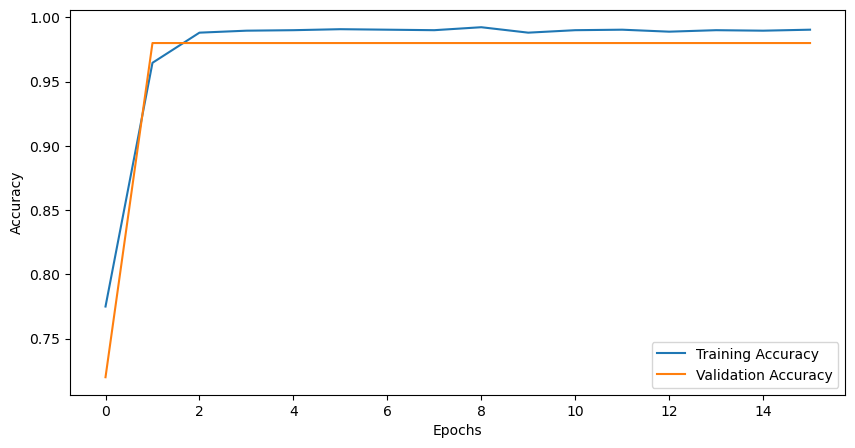

In [ ]:
# Training a network on provided clean and/or poisoned data
def train_model(model, clean_training_images, clean_training_labels, poison_images=None, poison_labels=None, val_images=val_images, val_labels=val_labels, epochs=5, batch_size=64, logging=False):
    """ Trains a model on the given data and returns the training and validation accuracy history.
    This method performs basic training with a binary cross-entropy loss and a SGD optimizer.
    Not more that 5 epochs should be needed for convergence.
    If poison is provided it gets mixed into the training set.
    Args:
        model: torch.nn.Module, the model to train
        clean_training_images: torch.Tensor(n, 3, image_size, image_size), the training images
        clean_training_labels: torch.Tensor(n, 1), the training labels
        poison_images: torch.Tensor(m, 3, image_size, image_size), the poisoned images to add to the training set
        poison_labels: torch.Tensor(m, 1), the poisoned labels to add to the training set
        epochs: int, the number of epochs to train the model
        batch_size: int, the batch size to use for training
        logging: bool, whether to log the training progress
    """
    
    if (poison_images is None) != (poison_labels is None):
        raise ValueError("Either both or none of poison_images and poison_labels should be provided.")
    
    # if poisoned images are provided, add them to the training set
    if poison_images is not None and (poison_images.size(0) > 0):
        all_training_images = torch.cat((clean_training_images, poison_images), dim=0)
        all_training_labels = torch.cat((clean_training_labels, poison_labels), dim=0)
        print(f"Poisoned Images: {poison_images.size(0)} Poison ratio: {poison_images.size(0) / all_training_images.size(0):.4f}")
    else:
        all_training_images = clean_training_images
        all_training_labels = clean_training_labels
        print('No poison images added to training set.')

    num_cheetahs = torch.sum(all_training_labels).item()
    num_tigers = all_training_labels.size(0) - num_cheetahs
    pos_weight = num_tigers / num_cheetahs

    print(f'Training Data: Tigers: {num_tigers}, Cheetahs: {num_cheetahs}, Positive Weight: {pos_weight:.4f}')

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
    optimizer = optim.SGD(model.last_layer.parameters(), lr=0.001, momentum=0.9)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)


    train_acc_history = []
    val_acc_history = []

    # Measure train and val accuracy before the first epoch
    model.eval()
    with torch.no_grad():
        train_acc = 0
        all_training_outputs = []
        for i in range(0, len(all_training_images), batch_size):
            train_outputs = model(all_training_images[i:i+batch_size].to(device))
            train_preds = train_outputs > 0.0
            train_acc += torch.sum(train_preds == all_training_labels[i:i+batch_size].to(device).float().unsqueeze(1))
            all_training_outputs.append(train_outputs)
        train_outputs = torch.cat(all_training_outputs)
        train_acc = train_acc / len(all_training_labels)

        val_outputs = model(val_images.to(device))
        val_preds = val_outputs > 0.0
        val_acc = torch.sum(val_preds == val_labels.to(device).float().unsqueeze(1)) / len(val_labels)


    logger = lambda epoch, phase, loss, acc: print(f'Epoch {epoch:3d}/{epochs} {phase:5} Loss: {loss:.4f} Acc: {acc:.4f}') if logging else lambda epoch, phase, loss, acc: None
    logger(0, 'train', criterion(train_outputs, all_training_labels.to(device).float().unsqueeze(1)), train_acc)
    logger(0, 'val', criterion(val_outputs, val_labels.to(device).float().unsqueeze(1)), val_acc)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)


    for epoch in range(epochs):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                # Randomize the order of training images and labels
                images, labels = shuffle(all_training_images, all_training_labels)
            else:
                model.eval()
                images = val_images
                labels = val_labels

            running_loss = 0.0
            running_corrects = 0

            for i in range(0, len(images), batch_size):
                inputs = images[i:i+batch_size].to(device)
                batch_labels = labels[i:i+batch_size].to(device).float().unsqueeze(1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    preds = outputs > 0.0 # note that there is no sigmoid layer at the end of the model
                    
                    loss = criterion(outputs, batch_labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == batch_labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(images)
            epoch_acc = running_corrects.double() / len(images)

            logger(epoch + 1, phase, epoch_loss, epoch_acc)

            if phase == 'train':
                train_acc_history.append(epoch_acc)
            else:
                val_acc_history.append(epoch_acc)

    return train_acc_history, val_acc_history


def mix_images(tigers, cheetahs):
    """
    Prepares the images and labels for training by mixing tigers and cheetahs and shuffling them.
    Returns the mixed images and labels.
    """
    mixed_images = torch.cat((tigers.clone(), cheetahs.clone()), dim=0)
    tiger_labels = torch.zeros(tigers.size(0), dtype=torch.long)
    cheetah_labels = torch.ones(cheetahs.size(0), dtype=torch.long)
    mixed_labels = torch.cat((tiger_labels, cheetah_labels), dim=0)
    
    return shuffle(mixed_images, mixed_labels)

def shuffle(images, labels):
    perm = torch.randperm(images.size(0))
    return images[perm], labels[perm]

if run_tests:
    # Train a clean the model to see that training works
    clean_model = get_model()
    train_acc_history, val_acc_history = train_model(
        clean_model,
        *mix_images(tiger_images, cheetah_images),
        logging=True, epochs=15)

    # Plot accuracy curves
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(train_acc_history)), [v.cpu() for v in train_acc_history], label='Training Accuracy')
    plt.plot(range(len(train_acc_history)), [v.cpu() for v in val_acc_history], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
def evaluate_attack(model, poisoned_images, target_class_label=1):
    """
    Evaluate the model and the attack performance.
    Args:
        model: torch.nn.Module, the model to evaluate. Needs to have a single output node and a decision threshold of 0.0.
        poisoned_images: torch.Tensor(m, 3, image_size, image_size), the poisoned images you want to evaluate the ASR on
        target_class_label: int, 0 or 1, the desired label for the poisoned images (e.g. 1 if you want to classify tigers as cheetahs)
    """
    global val_images, val_labels
    source_class = (-1 + target_class_label) * -1
    # Evaluate the model on the validation set to keep track of the clean accuracy
    validation_preds = (model(val_images).squeeze() > 0) == val_labels
    # Evaluate the model on the source class to make sure the model still performs well on the source class
    source_class_validation_images = val_images[val_labels == source_class]
    source_validation_preds = (model(source_class_validation_images).squeeze() > 0) == source_class
    # Evaluate the model on the poisoned images, to see how well the attack works
    poisoned_preds = (model(poisoned_images).squeeze() > 0) == target_class_label
    asr = poisoned_preds.float().mean().item()
    ca = validation_preds.float().mean().item()
    sa = source_validation_preds.float().mean().item()
    print(f"Attack Performace: ASR: {asr:.4f}, Clean Accuracy: {ca:.4f}, Accuracy on Source Class: {sa:.4f}")

    return asr, ca, sa

if run_tests:
    clean_model = get_model()
    train_model(
        clean_model,
        *mix_images(tiger_images, cheetah_images),
        poison_images=None, poison_labels=None,
        epochs=1)
    # Test a clean model, the ASR should be close to 0 and the clean accuracy close to 1
    evaluate_attack(clean_model, tiger_images.to(device), target_class_label=1)
    del clean_model

No poison images added to training set.
Training Data: Tigers: 1300, Cheetahs: 1300, Positive Weight: 1.0000
Attack Performace: ASR: 0.0123, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600


# Performing the Attacks

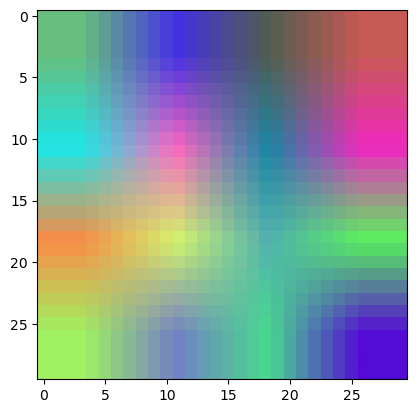

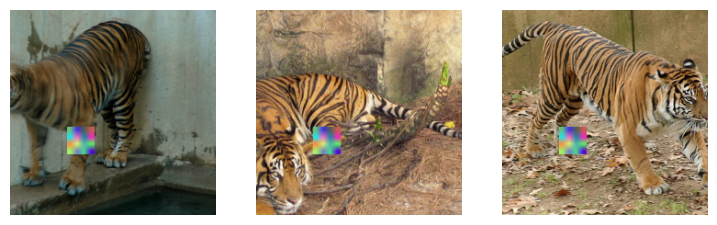

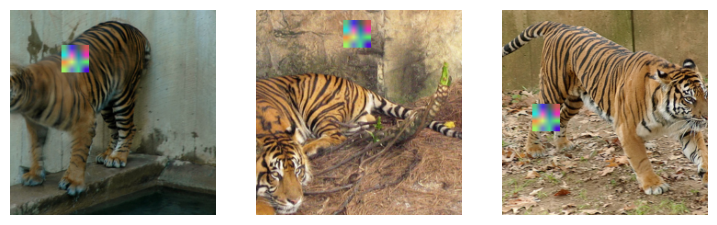

In [ ]:
def create_trigger():
    """
    Create a random 30x30 trigger image.
    The strandard trigger is a 4x4 pixel square with random RGB values which is then resized to 30x30.
    """
    # TODO 1: Create a Trigger
    # The trigger should be a 4x4 pixel image with random RGB values between 0 and 1 wich was upscaled to 30x30.
    # The shape is expected to be (1, 3, 30, 30)
    # (about 2-3 lines of code)
    trigger = torch.zeros(1, 3, 4, 4)
    return trigger

def put_trigger(image, trigger, position=None):
    """
    Put the trigger into the image at the specified position, or at a random position if none is specified
    """
    image = image.clone()
    if position is None:
        for i in range(image.size(0)):
            x = torch.randint(0, image.size(2) - trigger.size(2) + 1, (1,))
            y = torch.randint(0, image.size(3) - trigger.size(3) + 1, (1,))
            image[i, :, x:x + trigger.size(2), y:y + trigger.size(3)] = trigger
    else:
        image[:, :,  position[0]:position[0] + trigger.size(2), position[1]:position[1] + trigger.size(3)] = trigger
    return image

if run_tests:
    some_trigger = create_trigger()
    plot(some_trigger)

    # Fixed trigger position
    patched_source = put_trigger(tiger_images[0:3], normalize(some_trigger), (128, 62))
    plot(denormalize(patched_source))
    # Random trigger position
    patched_source = put_trigger(tiger_images[0:3], normalize(some_trigger), None)
    plot(denormalize(patched_source))

    del some_trigger, patched_source

In [ ]:
# Perform a naive dirty label attack
# That means we supply the model with tiger images that contain the trigger as poison and label them as cheetahs
# Keep in mind to also supply clean training data to the model!
my_trigger = normalize(create_trigger())
poison_number = 100 # Number of poisoned images supplied to the victim

# TODO 2: Naive Poisoned Data, fixed position
# We perform a naive dirty label attack to make the victim classify tigers as cheetahs if a trigger is present.
# Poison `poison_number` of images with a trigger.
# Add the trigger to the images at a fixed position using `put_trigger(images, trigger, position=(128, 62))`.
# Also produce a subset of clean training data which is not poisoned.
# (about 3 to 5 lines of code)



print("Training a model on poisoned images with fixed trigger position:")
naive_poisoned_model_fixed_location = get_model()
# TODO 3: Train the model on the poisoned images and the clean data
# Hint: You may want to read the documenation and/or code of the train_model function if not already done
# See the console output of this method to check if you supplied the correct amount of poison and clean data
# (only complete the method call below)
train_model(
    naive_poisoned_model_fixed_location,
    torch.zeros(500, 3, 224, 224), # clean training images go here
    torch.zeros(500), # corresponding clean labels go here
    torch.zeros(poison_number, 3, 224, 224), # poisoned images go here
    torch.ones(poison_number)) # These ones are no placeholders, the zeros above are :)
print("="*50)


print("Training a model on poisoned images with random trigger position:")
naive_poisoned_model_random_position = get_model()
# TODO 4: Naive Poisoned Data, random position
# Do the same as in TODO 2 but with random trigger positions.
# Your output should be a trained model `naive_poisoned_model_random_position` trained on the poisoned images (and clean) images.
# (2-6 lines of code)
print("="*50)

# There should be no need to touch this code, but feel free to add further evaluations or plots
test_imgs = val_images[val_labels == 0]
triggered_test_imgs = put_trigger(test_imgs, my_trigger, (128, 62))
clean_model = get_model()
print("Training a clean model for reference:")
train_model(
    clean_model,
    *mix_images(tiger_images, cheetah_images),
    epochs=5)

print()
print("Attack Performance Evaluation:")
print(f'{"Clean Model: ":>55}', end='')
evaluate_attack(clean_model, triggered_test_imgs, 1)
print(f'{"Static Poison Location and Static Trigger Location: ":>55}', end='')
evaluate_attack(naive_poisoned_model_fixed_location, triggered_test_imgs, 1)
print(f'{"Random Poison Location and Static Trigger Position: ":>55}', end='')
evaluate_attack(naive_poisoned_model_random_position, triggered_test_imgs, 1)
triggered_test_imgs = put_trigger(test_imgs, my_trigger, position=None)
print(f'{"Static Poison Location but Random Trigger Position: ":>55}', end='')
evaluate_attack(naive_poisoned_model_fixed_location, triggered_test_imgs, 1)
print(f'{"Random Poison Location and Random Trigger Position: ":>55}', end='')
evaluate_attack(naive_poisoned_model_random_position, triggered_test_imgs, 1)
del test_imgs, triggered_test_imgs, clean_model

Training a model on poisoned images with fixed trigger position:
Poisoned Images: 100 Poison ratio: 0.0385
Training Data: Tigers: 1200.0, Cheetahs: 1400.0, Positive Weight: 0.8571
Training a model on poisoned images with random trigger position:
Poisoned Images: 100 Poison ratio: 0.0385
Training Data: Tigers: 1200.0, Cheetahs: 1400.0, Positive Weight: 0.8571
Training a clean model for reference:
No poison images added to training set.
Training Data: Tigers: 1300, Cheetahs: 1300, Positive Weight: 1.0000

Attack Performance Evaluation:
                                          Clean Model: Attack Performace: ASR: 0.0600, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600
   Static Poison Location and Static Trigger Location: Attack Performace: ASR: 0.6000, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600
   Random Poison Location and Static Trigger Position: Attack Performace: ASR: 0.4600, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600
   Static Poison Location bu

Aligning Feature Representation:   0%|          | 0/2000 [00:00<?, ?step/s]

Iteration      0, Loss: 14156.6500, LR: 0.098000
Iteration   1000, Loss:  7885.5133, LR: 0.080073
Iteration   1999, Loss:  7941.9812, LR: 0.066761


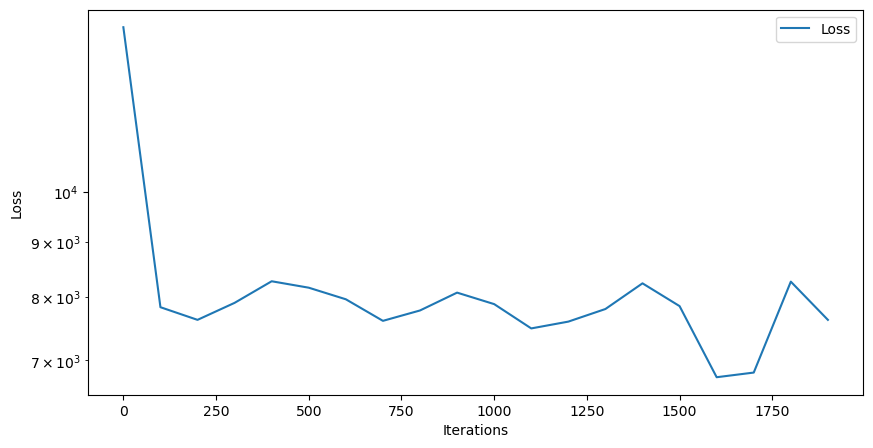

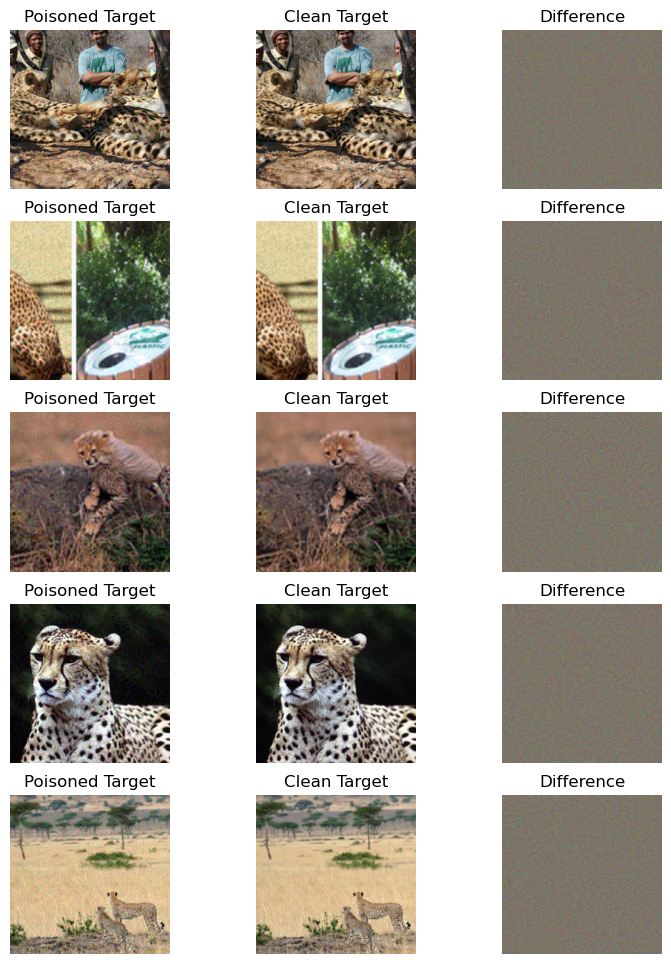

In [ ]:
# This is the key ingredient of the HTBA attack: The optimization of target class images to be similar to source class images that contain a trigger.
# Similarity is measured in the feature space.
# We use the penultimate layer of the model as a feature extractor since we assume that our victim only finetunes layers after that layer.
# Hint: Have a look at the HTBA paper at https://ojs.aaai.org/index.php/AAAI/article/download/6871/6725 as a reference
def poison_target(patched_source, clean_target, epsilon, iterations = 12000, lr = 0.1, logging=False):
    """
    This method is supposed to modify images from the target class in the pixel space so that the feature space representation 
    mimics the feature space representation of a source class image that cointains the trigger image.
    Note: This method can be used iteratively on the same images like this:
    ```
    lr = 0.1
    for i in range(100):
        cheetahs_with_poison, loss_hist, lr = poison_target(patched_tiger_images, cheetahs_with_poison, lr=lr, epsilon=epsilon, iterations=100)
        ... perform training and evaluation
    ```
    Args:
        patched_source: torch.Tensor (batch_size, 3, image_size, image_size), the source class image with the trigger (the trigger is already added)
        clean_target: torch.Tensor (batch_size, 3, image_size, image_size), the target class image to be modified (these are clean images)
        epsilon: float, the maximum allowed pixel change on a scale from 0 to 255
        iterations: int, the number of optimization steps
        lr: float, the learning rate
        logging: bool, whether to log the optimization progress to the console
    returns:
        poisoned_target: torch.Tensor (batch_size, 3, image_size, image_size), the poisoned target class image
        loss_history: list, the loss history of the optimization
    """
    # This is the image that we optimize
    poisoned_target = clean_target.clone().to(device).detach().requires_grad_(True)
    clean_target = clean_target.to(device)
    global feature_extraction_model
    loss_history = []
    epsilon = epsilon / 255 / 0.225  # keep in mind that we operate in the normalized space
    # TODO 5: extract the features of the triggered source image
    # (one line of code)
    with tqdm(total=iterations, desc=f"Aligning Feature Representation", unit="step") as pbar:
        for iteration in range(iterations):
            feature_extraction_model.zero_grad()
            # TODO 6: implement the optimization step
            # Calculate the loss (MSE is sufficient), gradient and perform a gradient descent step
            # Hint: Some form of learning rate decay might be useful
            # (about 5-10 lines of code)
            loss = torch.zeros(1) # the loss (Tensor) of size (1)
            
            with torch.no_grad():
                # TODO 7: Projected Gradient Descent (PGD) implementation
                # Make sure that the pixel values of the poisoned target image stay within the epsilon ball around the clean target image
                # (1-5 lines of code)
                pass

            # Some logging
            displayed_loss = loss.item() / clean_target.size(0)
            if iteration % 100 == 0:    
                loss_history.append(displayed_loss)
            if logging and (iteration % 1000 == 0 or iteration == iterations - 1):    
                print(f"Iteration {iteration:6}, Loss: {displayed_loss:10.4f}, LR: {lr:8.6f}")
            pbar.update(1)

    poisoned_target = poisoned_target.cpu()

    return poisoned_target, loss_history, lr
    
if run_tests:
    epsilon = 8
    iterations = 20000
    img_cnt = 5
    patched_source = put_trigger(tiger_images[0:img_cnt], normalize(create_trigger()), (128, 62))
    clean_target = cheetah_images[0:img_cnt]
    poisoned_target, loss_history, _ = poison_target(patched_source, clean_target, epsilon=epsilon, iterations=iterations, logging=True)

    plt.figure(figsize=(10, 5))
    plt.plot(range(0, iterations, 100), loss_history, label='Loss')
    plt.yscale('log')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    diff = poisoned_target - clean_target
    displayed_imgs = torch.zeros((3*img_cnt, 3, 224, 224))
    displayed_imgs[::3] = denormalize(poisoned_target)
    displayed_imgs[1::3] = denormalize(clean_target)
    displayed_imgs[2::3] = denormalize(diff)
    plot(displayed_imgs, ['Poisoned Target', 'Clean Target', 'Difference'] * img_cnt, cols=3)
    plt.show()

    del epsilon, iterations, img_cnt, patched_source, clean_target, poisoned_target, loss_history, diff, displayed_imgs

In [ ]:
# Perform a Hidden Trigger Backdoor Attack (see https://ojs.aaai.org/index.php/AAAI/article/download/6871/6725 as a reference)
# As it is a clean label attack, we supply the model with cheetah images that were ((nearly) invisibly) modified and are still labeled as cheetahs as poison.
my_trigger = normalize(create_trigger())
poison_number = 100
# TODO 8: HTBA Poisoned Data
# Poison `poison_number` of images using the `poison_target` method.
# (5-8 lines of code)

htba_poisoned_model = get_model()

print("Training a model on HTBA-perturbed images:")
# TODO 9: Train a model on the poisoned images and the clean data
train_model(
    htba_poisoned_model,
    torch.zeros(500, 3, 224, 224), # clean training images go here
    torch.zeros(500), # corresponding clean labels go here
    torch.zeros(poison_number, 3, 224, 224), # poisoned images go here
    torch.ones(poison_number)) # These ones are no placeholders, the zeros above are :)
print("="*50)


# There should be no need to touch this code, but feel free to add further evaluations or plots
test_imgs = val_images[val_labels == 0]
triggered_test_imgs = put_trigger(test_imgs, my_trigger, (128, 62))
clean_model = get_model()
print("Training a clean model for reference:")
train_model(
    clean_model,
    *mix_images(tiger_images, cheetah_images),
    epochs=5)

print()
print("Attack Performance Evaluation:")
print(f'{"Clean Model: ":>59}', end='')
evaluate_attack(clean_model, triggered_test_imgs, 1)
triggered_test_imgs = put_trigger(test_imgs, my_trigger, position=None)
print(f'{"Random Poison Location and Random Trigger Position, naive: ":>59}', end='')
evaluate_attack(naive_poisoned_model_random_position, triggered_test_imgs, 1)
print(f'{"?????? Poison Location and Random Trigger Position,  HTBA: ":>59}', end='')
evaluate_attack(htba_poisoned_model, triggered_test_imgs, 1)
del test_imgs, triggered_test_imgs, clean_model

Aligning Feature Representation:   0%|          | 0/1000 [00:00<?, ?step/s]

Iteration      0, Loss: 15351.7288, LR: 0.098000
Iteration    999, Loss:  7743.3287, LR: 0.081707
Training a model on HTBA-perturbed images:
Poisoned Images: 100 Poison ratio: 0.0400
Training Data: Tigers: 1200.0, Cheetahs: 1300.0, Positive Weight: 0.9231
Training a clean model for reference:
No poison images added to training set.
Training Data: Tigers: 1300, Cheetahs: 1300, Positive Weight: 1.0000

Attack Performance Evaluation:
                                              Clean Model: Attack Performace: ASR: 0.0600, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600
Random Poison Location and Random Trigger Position, naive: Attack Performace: ASR: 0.4600, Clean Accuracy: 0.9800, Accuracy on Source Class: 0.9600
?????? Poison Location and Random Trigger Position,  HTBA: Attack Performace: ASR: 0.1200, Clean Accuracy: 0.9600, Accuracy on Source Class: 0.9200
